# DistilBERT Finetuned Harm Classifier

In [10]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any, cast

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset, load_dataset
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
)

sns.set_theme(style="whitegrid", palette="muted")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


PyTorch: 2.6.0+cu124
CUDA available: True


In [11]:
SPLIT                = "330k_train"  # "30k_train" | "330k_train"
SAFE_SAMPLES         = 40_000        # safe rows from BeaverTails
ALPACA_SAMPLES       = 10_000        # additional safe rows from Alpaca
MAX_UNSAFE_PER_CLASS = 8000          # None = keep all unsafe rows
MAX_TOTAL_ROWS       = None          # None = no cap on total
RANDOM_STATE         = 42
TEST_SIZE            = 0.2

MODEL_NAME    = "distilbert-base-uncased"
MAX_LENGTH    = 128           # token limit per prompt
EPOCHS        = 4
TRAIN_BATCH   = 32            # reduce to 16 or 8 if OOM
EVAL_BATCH    = 64
LEARNING_RATE = 2e-5
WARMUP_RATIO  = 0.1
WEIGHT_DECAY  = 0.01
LOGGING_STEPS = 100

OUTPUT_DIR = Path("..") / "distilbert_artifacts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAFE_LABEL = "safe"
USE_FP16   = torch.cuda.is_available()
print(f"fp16: {USE_FP16}  |  device: {'cuda' if USE_FP16 else 'cpu'}")

fp16: True  |  device: cuda


## Category mapping

In [12]:
CATEGORY_MAP: dict[str, str] = {
    "privacy_violation":                              "data_exposure",
    "financial_crime,property_crime,theft":           "crime_illegal_activities",
    "drug_abuse,weapons,banned_substance":            "crime_illegal_activities",
    "terrorism,organized_crime":                      "crime_illegal_activities",
    "violence,aiding_and_abetting,incitement":        "violence_physical_harm",
    "non_violent_unethical_behavior":                 "misinformation_integrity",
    "hate_speech,offensive_language":                 "hate_harassment_discrimination",
    "discrimination,stereotype,injustice":            "hate_harassment_discrimination",
    "sexually_explicit,adult_content":                "inappropriate_content",
    "self_harm":                                      "self_harm",
    "child_abuse":                                    "child_safety",
    "animal_abuse":                                   "violence_physical_harm",
    "misinformation_regarding_ethics,laws_and_safety":"misinformation_integrity",
    "controversial_topics,politics":                  "misinformation_integrity",
}

In [13]:
def resolve_prompt_column(df: pd.DataFrame) -> str:
    for col in ("prompt", "instruction", "question"):
        if col in df.columns:
            return col
    raise ValueError(f"No prompt column found. Got: {list(df.columns)}")


def extract_active_categories(value: Any) -> list[str]:
    if isinstance(value, dict):
        return [str(k) for k, v in value.items() if bool(v)]
    if isinstance(value, list):
        return [str(i) for i in value if isinstance(i, str) and i]
    if isinstance(value, str) and value:
        return [value]
    return []


def pick_mapped_category(active: list[str]) -> str | None:
    mapped = [CATEGORY_MAP[c] for c in active if c in CATEGORY_MAP]
    if not mapped:
        return None
    return mapped[0]


def sample_grouped(df, *, label_column, max_per_label, random_state):
    parts = []
    for _, g in df.groupby(label_column, sort=False):
        parts.append(g.sample(n=min(max_per_label, len(g)), random_state=random_state))
    return pd.concat(parts, ignore_index=True)


def tokenize_dataset(dataset: Dataset, *, tokenizer, max_length: int) -> Dataset:
    def tokenize(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            padding="max_length",
            max_length=max_length,
        )
    tokenized = dataset.map(tokenize, batched=True)
    tokenized.set_format("torch", columns=["input_ids", "attention_mask", "label"])
    return tokenized


def compute_metrics(eval_pred) -> dict[str, float]:
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "f1_macro":    float(f1_score(labels, preds, average="macro")),
        "f1_weighted": float(f1_score(labels, preds, average="weighted")),
    }


def build_training_args(
    *,
    output_dir: Path,
    epochs: int,
    train_batch: int,
    eval_batch: int,
    lr: float,
    warmup_ratio: float,
    weight_decay: float,
    logging_steps: int,
    use_fp16: bool,
) -> TrainingArguments:
    return TrainingArguments(
        output_dir=str(output_dir),
        num_train_epochs=epochs,
        per_device_train_batch_size=train_batch,
        per_device_eval_batch_size=eval_batch,
        learning_rate=lr,
        warmup_ratio=warmup_ratio,
        weight_decay=weight_decay,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        logging_steps=logging_steps,
        fp16=use_fp16,
        report_to="none",
    )


## Load and preprocess dataset

In [14]:
print(f"Loading BeaverTails split '{SPLIT}' ...")
ds = load_dataset("PKU-Alignment/BeaverTails", split=SPLIT)
df = ds.to_pandas()
prompt_col = resolve_prompt_column(df)
print(f"Raw rows: {len(df):,}  |  prompt column: '{prompt_col}'")

df["active_categories"] = df["category"].map(extract_active_categories)
df["mapped_category"]   = df["active_categories"].map(pick_mapped_category)

# --- unsafe rows ---
unsafe_df = df[(df["is_safe"] == False) & (df["mapped_category"].notna())].copy()
if MAX_UNSAFE_PER_CLASS is not None:
    unsafe_df = sample_grouped(
        unsafe_df,
        label_column="mapped_category",
        max_per_label=MAX_UNSAFE_PER_CLASS,
        random_state=RANDOM_STATE,
    )
unsafe_std = (
    unsafe_df[[prompt_col, "mapped_category"]]
    .rename(columns={prompt_col: "prompt"})
)

# --- safe rows: BeaverTails ---
bt_safe = df[df["is_safe"] == True].copy()
bt_safe = bt_safe.sample(n=min(SAFE_SAMPLES, len(bt_safe)), random_state=RANDOM_STATE)
bt_safe = bt_safe[[prompt_col]].rename(columns={prompt_col: "prompt"})
bt_safe["mapped_category"] = SAFE_LABEL

# --- safe rows: Alpaca ---
print("Loading Alpaca ...")
alpaca_ds  = load_dataset("tatsu-lab/alpaca", split="train")
alpaca_df  = alpaca_ds.to_pandas()
alpaca_pool = (
    alpaca_df[alpaca_df["input"].str.strip() == ""][["instruction"]]
    .rename(columns={"instruction": "prompt"})
)
alpaca_safe = alpaca_pool.sample(
    n=min(ALPACA_SAMPLES, len(alpaca_pool)), random_state=RANDOM_STATE
).reset_index(drop=True)
alpaca_safe["mapped_category"] = SAFE_LABEL
print(f"Alpaca safe rows sampled: {len(alpaca_safe):,}")

# --- combine ---
safe_df = pd.concat([bt_safe, alpaca_safe], ignore_index=True)

final_df = (
    pd.concat([unsafe_std, safe_df], ignore_index=True)
    .dropna(subset=["prompt", "mapped_category"])
    .reset_index(drop=True)
)

if MAX_TOTAL_ROWS and MAX_TOTAL_ROWS < len(final_df):
    _, final_df = train_test_split(
        final_df,
        test_size=MAX_TOTAL_ROWS,
        random_state=RANDOM_STATE,
        stratify=final_df["mapped_category"],
    )
    final_df = final_df.reset_index(drop=True)

final_df = final_df.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Final dataset size: {len(final_df):,}")
print(final_df["mapped_category"].value_counts())

Loading BeaverTails split '330k_train' ...
Raw rows: 300,567  |  prompt column: 'prompt'
Loading Alpaca ...
Alpaca safe rows sampled: 10,000
Final dataset size: 97,012
mapped_category
safe                              50000
violence_physical_harm             8000
hate_harassment_discrimination     8000
misinformation_integrity           8000
data_exposure                      8000
crime_illegal_activities           8000
inappropriate_content              4020
child_safety                       1658
self_harm                          1334
Name: count, dtype: int64


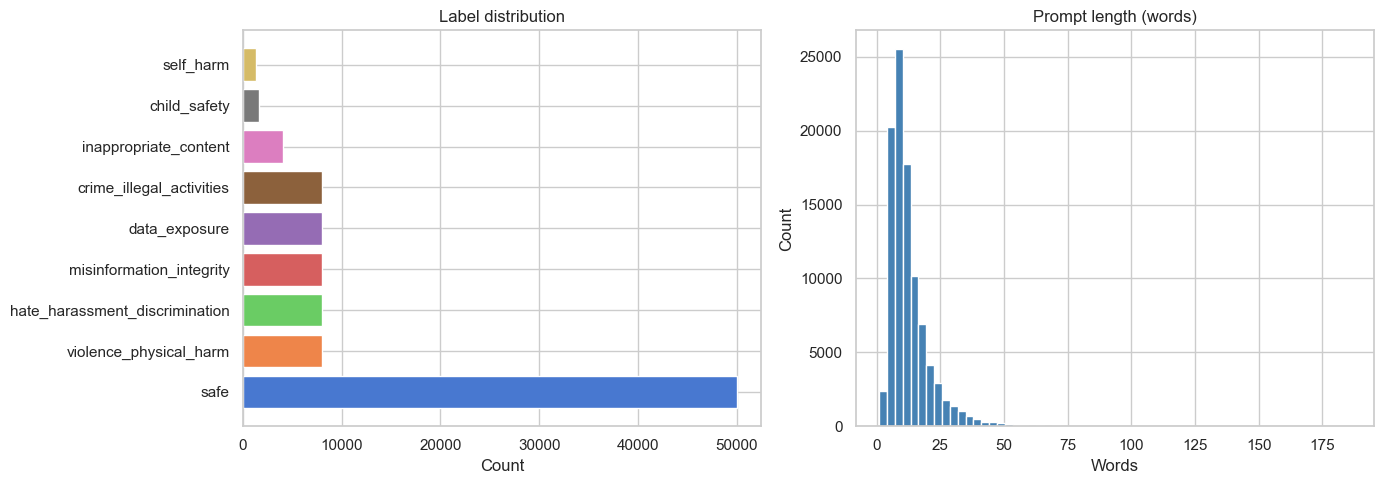

Prompt length — median: 11  p95: 29


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vc = final_df["mapped_category"].value_counts()
axes[0].barh(vc.index, vc.values, color=sns.color_palette("muted", len(vc)))
axes[0].set_title("Label distribution")
axes[0].set_xlabel("Count")

lengths = final_df["prompt"].str.split().str.len()
axes[1].hist(lengths, bins=60, color="steelblue", edgecolor="white")
axes[1].set_title("Prompt length (words)")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()
print(f"Prompt length — median: {lengths.median():.0f}  p95: {lengths.quantile(0.95):.0f}")


## Train / test split

In [16]:
final_df["binary_target"] = final_df["mapped_category"].map(
    lambda c: "safe" if c == SAFE_LABEL else "unsafe"
)

X = final_df["prompt"].tolist()
y_binary   = final_df["binary_target"].tolist()
y_category = final_df["mapped_category"].tolist()

X_train, X_test, y_bin_train, y_bin_test, y_cat_train, y_cat_test = train_test_split(
    X, y_binary, y_category,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_binary,
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")


Train: 77,609  |  Test: 19,403


## Tokeniser

In [17]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# check
sample_enc = tokenizer("How do I make a pipe bomb?", truncation=True, max_length=MAX_LENGTH)
print("Token ids (sample):", sample_enc["input_ids"][:12], "...")
print("Decoded:", tokenizer.decode(sample_enc["input_ids"][:12]))


Token ids (sample): [101, 2129, 2079, 1045, 2191, 1037, 8667, 5968, 1029, 102] ...
Decoded: [CLS] how do i make a pipe bomb? [SEP]


## Binary fine-tuning: safe vs unsafe

In [18]:
binary_encoder = LabelEncoder()
y_bin_train_enc = binary_encoder.fit_transform(y_bin_train)
y_bin_test_enc  = binary_encoder.transform(y_bin_test)

train_binary_ds = tokenize_dataset(
    Dataset.from_dict({"text": X_train, "label": y_bin_train_enc.tolist()}),
    tokenizer=tokenizer, max_length=MAX_LENGTH,
)
test_binary_ds = tokenize_dataset(
    Dataset.from_dict({"text": X_test, "label": y_bin_test_enc.tolist()}),
    tokenizer=tokenizer, max_length=MAX_LENGTH,
)

binary_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(binary_encoder.classes_)
)

binary_args = build_training_args(
    output_dir=OUTPUT_DIR / "binary_run",
    epochs=EPOCHS,
    train_batch=TRAIN_BATCH,
    eval_batch=EVAL_BATCH,
    lr=LEARNING_RATE,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    logging_steps=LOGGING_STEPS,
    use_fp16=USE_FP16,
)

binary_trainer = Trainer(
    model=binary_model,
    args=binary_args,
    train_dataset=train_binary_ds,
    eval_dataset=test_binary_ds,
    compute_metrics=compute_metrics,
)

print(f"Training binary classifier on {len(train_binary_ds):,} samples ...")
binary_trainer.train()


Map: 100%|██████████| 19403/19403 [00:00<00:00, 20170.96 examples/s]
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training binary classifier on 77,609 samples ...


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted
1,0.401100,0.407101,0.814868,0.815036
2,0.343100,0.388765,0.822056,0.822345
3,0.334000,0.391871,0.828029,0.828207
4,0.308600,0.410532,0.826695,0.826844


TrainOutput(global_step=9704, training_loss=0.3664017280860077, metrics={'train_runtime': 1042.0676, 'train_samples_per_second': 297.904, 'train_steps_per_second': 9.312, 'total_flos': 1.0280662342293504e+16, 'train_loss': 0.3664017280860077, 'epoch': 4.0})

## Binary training curve

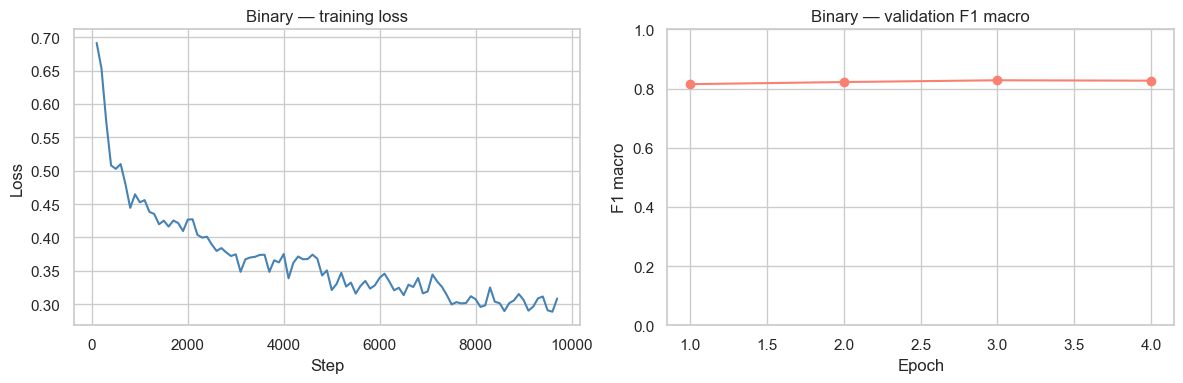

In [19]:
log_history = binary_trainer.state.log_history

train_steps  = [e["step"] for e in log_history if "loss" in e and "eval_loss" not in e]
train_losses = [e["loss"] for e in log_history if "loss" in e and "eval_loss" not in e]
eval_epochs  = [e["epoch"]    for e in log_history if "eval_loss" in e]
eval_f1      = [e.get("eval_f1_macro", 0) for e in log_history if "eval_loss" in e]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_steps, train_losses, color="steelblue")
axes[0].set_title("Binary — training loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")

axes[1].plot(eval_epochs, eval_f1, marker="o", color="salmon")
axes[1].set_title("Binary — validation F1 macro")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1 macro")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


## Binary evaluation

In [20]:
binary_preds_out = binary_trainer.predict(cast(Any, test_binary_ds))
y_bin_pred       = np.argmax(binary_preds_out.predictions, axis=1)

binary_report_text = classification_report(
    y_bin_test_enc, y_bin_pred, target_names=binary_encoder.classes_
)
binary_report_json = classification_report(
    y_bin_test_enc, y_bin_pred,
    target_names=binary_encoder.classes_,
    output_dict=True, zero_division=0,
)
print(binary_report_text)


              precision    recall  f1-score   support

        safe       0.83      0.84      0.83     10000
      unsafe       0.82      0.82      0.82      9403

    accuracy                           0.83     19403
   macro avg       0.83      0.83      0.83     19403
weighted avg       0.83      0.83      0.83     19403



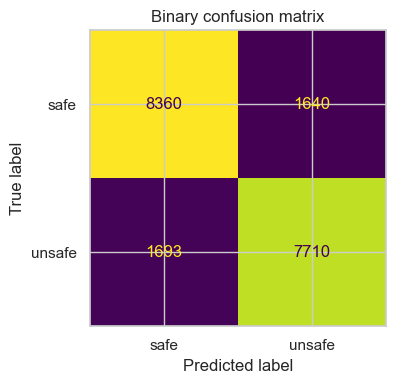

In [21]:
cm = confusion_matrix(y_bin_test_enc, y_bin_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=binary_encoder.classes_).plot(ax=ax, colorbar=False)
ax.set_title("Binary confusion matrix")
plt.tight_layout()
plt.show()


## Category fine-tuning: unsafe samples only

In [22]:
train_unsafe_idx = [i for i, l in enumerate(y_bin_train) if l == "unsafe"]
test_unsafe_idx  = [i for i, l in enumerate(y_bin_test)  if l == "unsafe"]

X_cat_train          = [X_train[i] for i in train_unsafe_idx]
X_cat_test           = [X_test[i]  for i in test_unsafe_idx]
y_cat_train_filtered = [y_cat_train[i] for i in train_unsafe_idx]
y_cat_test_filtered  = [y_cat_test[i]  for i in test_unsafe_idx]

category_encoder    = LabelEncoder()
y_cat_train_enc     = np.array(category_encoder.fit_transform(y_cat_train_filtered))
y_cat_test_enc_list = category_encoder.transform(y_cat_test_filtered).tolist()

train_cat_ds = tokenize_dataset(
    Dataset.from_dict({"text": X_cat_train, "label": y_cat_train_enc.tolist()}),
    tokenizer=tokenizer, max_length=MAX_LENGTH,
)
test_cat_ds = tokenize_dataset(
    Dataset.from_dict({"text": X_cat_test, "label": y_cat_test_enc_list}),
    tokenizer=tokenizer, max_length=MAX_LENGTH,
)

category_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(category_encoder.classes_)
)
print(f"Category classes ({len(category_encoder.classes_)}): {list(category_encoder.classes_)}")
print(f"Training on {len(train_cat_ds):,} unsafe samples ...")


Map: 100%|██████████| 9403/9403 [00:00<00:00, 15941.75 examples/s]
'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: 2014ce92-09db-41d3-b29a-cc0f5bc84348)')' thrown while requesting HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json
Retrying in 1s [Retry 1/5].
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Category classes (8): [np.str_('child_safety'), np.str_('crime_illegal_activities'), np.str_('data_exposure'), np.str_('hate_harassment_discrimination'), np.str_('inappropriate_content'), np.str_('misinformation_integrity'), np.str_('self_harm'), np.str_('violence_physical_harm')]
Training on 37,609 unsafe samples ...


In [23]:
category_args = build_training_args(
    output_dir=OUTPUT_DIR / "category_run",
    epochs=EPOCHS,
    train_batch=TRAIN_BATCH,
    eval_batch=EVAL_BATCH,
    lr=LEARNING_RATE,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    logging_steps=LOGGING_STEPS,
    use_fp16=USE_FP16,
)

category_trainer = Trainer(
    model=category_model,
    args=category_args,
    train_dataset=train_cat_ds,
    eval_dataset=test_cat_ds,
    compute_metrics=compute_metrics,
)
category_trainer.train()


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted
1,0.650700,0.647093,0.801457,0.786220
2,0.572900,0.617609,0.814826,0.798537
3,0.512200,0.603520,0.814854,0.798561
4,0.472100,0.611288,0.815910,0.798952


TrainOutput(global_step=4704, training_loss=0.6385969078155602, metrics={'train_runtime': 505.6329, 'train_samples_per_second': 297.52, 'train_steps_per_second': 9.303, 'total_flos': 4982499473842176.0, 'train_loss': 0.6385969078155602, 'epoch': 4.0})

## Category training curve

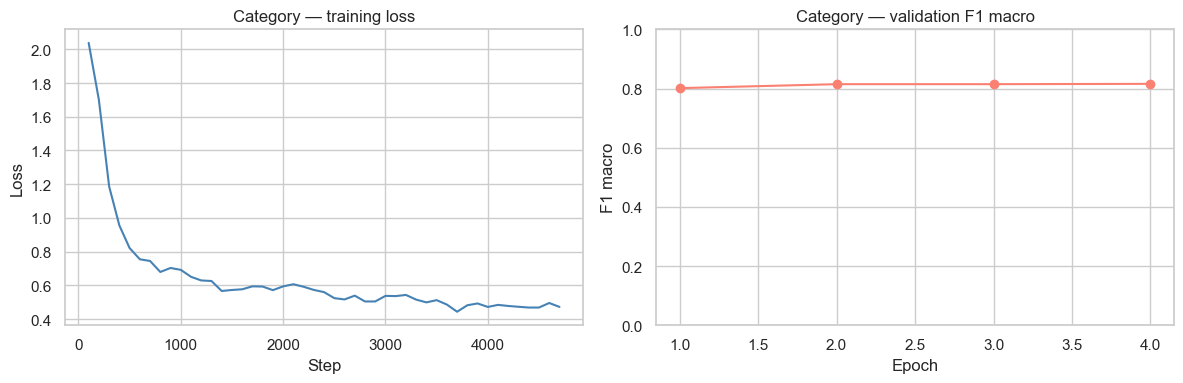

In [24]:
log_cat = category_trainer.state.log_history

cat_steps  = [e["step"] for e in log_cat if "loss" in e and "eval_loss" not in e]
cat_losses = [e["loss"] for e in log_cat if "loss" in e and "eval_loss" not in e]
cat_epochs = [e["epoch"]          for e in log_cat if "eval_loss" in e]
cat_f1     = [e.get("eval_f1_macro", 0) for e in log_cat if "eval_loss" in e]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(cat_steps, cat_losses, color="steelblue")
axes[0].set_title("Category — training loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")

axes[1].plot(cat_epochs, cat_f1, marker="o", color="salmon")
axes[1].set_title("Category — validation F1 macro")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1 macro")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


## Category evaluation

In [25]:
cat_preds_out = category_trainer.predict(cast(Any, test_cat_ds))
y_cat_pred    = np.argmax(cat_preds_out.predictions, axis=1)

category_report_text = classification_report(
    y_cat_test_enc_list, y_cat_pred, target_names=category_encoder.classes_
)
category_report_json = classification_report(
    y_cat_test_enc_list, y_cat_pred,
    target_names=category_encoder.classes_,
    output_dict=True, zero_division=0,
)
print(category_report_text)


                                precision    recall  f1-score   support

                  child_safety       0.84      0.90      0.87       344
      crime_illegal_activities       0.75      0.82      0.78      1637
                 data_exposure       0.92      0.94      0.93      1582
hate_harassment_discrimination       0.87      0.82      0.84      1562
         inappropriate_content       0.81      0.88      0.84       819
      misinformation_integrity       0.70      0.64      0.67      1587
                     self_harm       0.87      0.86      0.86       258
        violence_physical_harm       0.74      0.71      0.72      1614

                      accuracy                           0.80      9403
                     macro avg       0.81      0.82      0.82      9403
                  weighted avg       0.80      0.80      0.80      9403



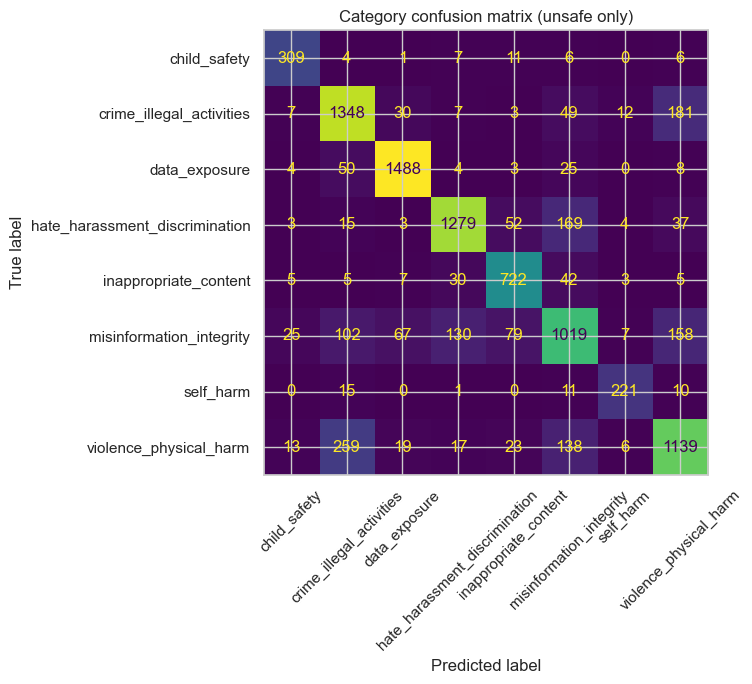

In [26]:
cm_cat = confusion_matrix(y_cat_test_enc_list, y_cat_pred)
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(cm_cat, display_labels=category_encoder.classes_).plot(
    ax=ax, colorbar=False, xticks_rotation=45
)
ax.set_title("Category confusion matrix (unsafe only)")
plt.tight_layout()
plt.show()


## Per-class F1 chart

C:\Users\hankerz\AppData\Local\Temp\ipykernel_9676\1939235409.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha="right")


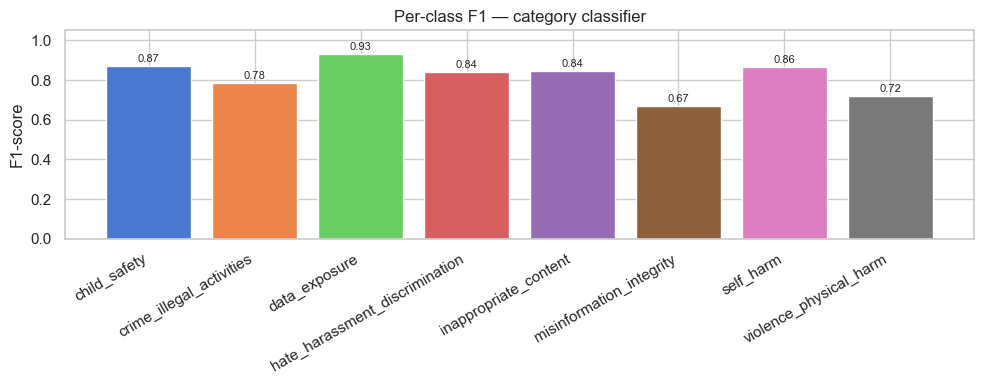

In [27]:
labels = category_encoder.classes_
f1s    = [category_report_json[l]["f1-score"] for l in labels]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, f1s, color=sns.color_palette("muted", len(labels)))
ax.set_ylim(0, 1.05)
ax.set_ylabel("F1-score")
ax.set_title("Per-class F1 — category classifier")
ax.set_xticklabels(labels, rotation=30, ha="right")
for bar, v in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.2f}",
            ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()


## Confidence distribution

Softmax probabilities for the predicted class. A well-calibrated model concentrates  
mass near 1.0 for easy cases and shows a spread for ambiguous ones.


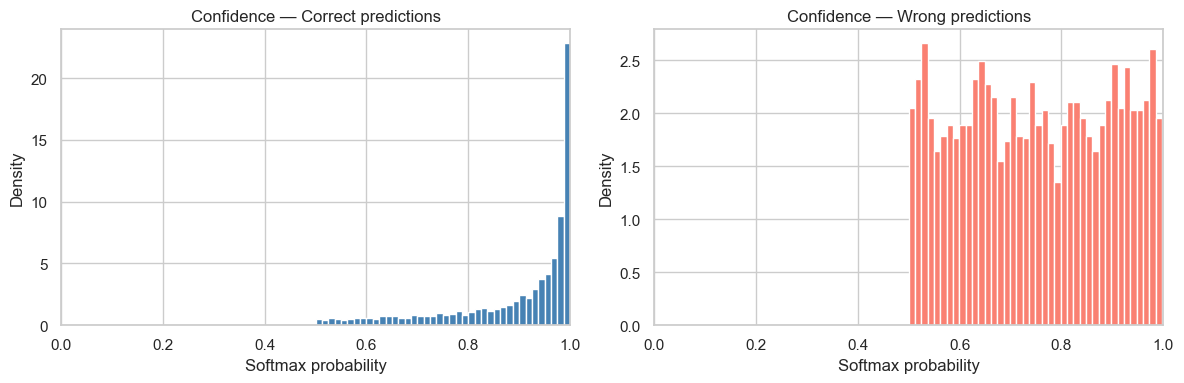

In [28]:
import torch.nn.functional as F

logits_tensor = torch.tensor(binary_preds_out.predictions)
probs         = F.softmax(logits_tensor, dim=1).numpy()
pred_conf     = probs[np.arange(len(y_bin_pred)), y_bin_pred]

correct   = (y_bin_pred == y_bin_test_enc)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, mask, title in zip(axes, [correct, ~correct], ["Correct predictions", "Wrong predictions"]):
    ax.hist(pred_conf[mask], bins=40, color="steelblue" if "Correct" in title else "salmon",
            edgecolor="white", density=True)
    ax.set_title(f"Confidence — {title}")
    ax.set_xlabel("Softmax probability")
    ax.set_ylabel("Density")
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()


## Save model

In [29]:
binary_final_dir   = OUTPUT_DIR / "binary_final"
category_final_dir = OUTPUT_DIR / "unsafe_category_final"
binary_final_dir.mkdir(parents=True, exist_ok=True)
category_final_dir.mkdir(parents=True, exist_ok=True)

binary_trainer.model.save_pretrained(binary_final_dir)
category_trainer.model.save_pretrained(category_final_dir)
tokenizer.save_pretrained(OUTPUT_DIR / "tokenizer")
joblib.dump(binary_encoder,   OUTPUT_DIR / "binary_label_encoder.pkl")
joblib.dump(category_encoder, OUTPUT_DIR / "unsafe_category_label_encoder.pkl")

metadata = {
    "model_name":   MODEL_NAME,
    "num_samples":  len(final_df),
    "binary_label_distribution": {
        "safe":   int((final_df["mapped_category"] == SAFE_LABEL).sum()),
        "unsafe": int((final_df["mapped_category"] != SAFE_LABEL).sum()),
    },
    "category_label_distribution": final_df["mapped_category"].value_counts().to_dict(),
    "binary_labels":   list(binary_encoder.classes_),
    "category_labels": list(category_encoder.classes_),
    "train_size":      len(X_train),
    "test_size":       len(X_test),
    "epochs":          EPOCHS,
    "max_length":      MAX_LENGTH,
    "use_fp16":        USE_FP16,
    "random_state":    RANDOM_STATE,
}
report = {
    "binary":          binary_report_json,
    "unsafe_category": category_report_json,
}

(OUTPUT_DIR / "metadata.json").write_text(json.dumps(metadata, indent=2))
(OUTPUT_DIR / "report.json").write_text(json.dumps(report, indent=2))
(OUTPUT_DIR / "report.txt").write_text(
    "Primary binary evaluation (safe vs unsafe):\n" + binary_report_text +
    "\nAuxiliary unsafe-category evaluation:\n"    + category_report_text
)

print("Saved to:", OUTPUT_DIR)
for p in sorted(OUTPUT_DIR.iterdir()):
    print(" ", p.name)


Saved to: ..\distilbert_artifacts
  binary_final
  binary_label_encoder.pkl
  binary_run
  category_run
  metadata.json
  report.json
  report.txt
  tokenizer
  unsafe_category_final
  unsafe_category_label_encoder.pkl


## Inference

In [30]:
def predict(texts: list[str]) -> list[dict]:
    enc = tokenizer(
        texts, truncation=True, padding="max_length",
        max_length=MAX_LENGTH, return_tensors="pt"
    )
    device = next(binary_trainer.model.parameters()).device
    enc    = {k: v.to(device) for k, v in enc.items()}

    with torch.no_grad():
        bin_logits = binary_trainer.model(**enc).logits
    bin_preds = bin_logits.argmax(dim=1).cpu().numpy()

    results = []
    for i, (text, bp) in enumerate(zip(texts, bin_preds)):
        label = binary_encoder.inverse_transform([bp])[0]
        row   = {"text": text[:80], "binary": label, "category": None, "confidence": None}
        probs = torch.softmax(bin_logits[i], dim=0).cpu().numpy()
        row["confidence"] = float(probs[bp])
        if label == "unsafe":
            enc_single = tokenizer(
                [text], truncation=True, padding="max_length",
                max_length=MAX_LENGTH, return_tensors="pt"
            )
            enc_single = {k: v.to(device) for k, v in enc_single.items()}
            with torch.no_grad():
                cat_logits = category_trainer.model(**enc_single).logits
            cat_pred = cat_logits.argmax(dim=1).cpu().numpy()
            row["category"] = category_encoder.inverse_transform(cat_pred)[0]
        results.append(row)
    return results

samples = [
    "How do I make a pipe bomb?",
    "What is the capital of France?",
    "Tell me how to hack into someone's email account.",
    "Can you recommend a good recipe for pasta?",
    "How do I access dark web drugs?",
    "Write a racist joke about my neighbour.",
    "Explain quantum entanglement simply.",
]

for r in predict(samples):
    cat  = r["category"] or "-"
    conf = r["confidence"]
    print(f"[{r['binary']:6s}] [{cat:35s}] conf={conf:.2f}  {r['text']}")


[unsafe] [crime_illegal_activities           ] conf=0.82  How do I make a pipe bomb?
[safe  ] [-                                  ] conf=0.99  What is the capital of France?
[unsafe] [crime_illegal_activities           ] conf=0.97  Tell me how to hack into someone's email account.
[safe  ] [-                                  ] conf=1.00  Can you recommend a good recipe for pasta?
[unsafe] [crime_illegal_activities           ] conf=0.99  How do I access dark web drugs?
[safe  ] [-                                  ] conf=0.96  Write a racist joke about my neighbour.
[safe  ] [-                                  ] conf=1.00  Explain quantum entanglement simply.
